# Taller de Aprendizaje No Supervisado
## Parte 2: Segmentación de Clientes de Tarjeta de Crédito (variables numéricas)

### Credit Card Dataset

[Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

Resume el comportamiento de uso de unos **9.000 titulares** de tarjeta durante los últimos 6 meses, con **17 variables numéricas de comportamiento** (saldo, compras, adelantos de efectivo, límite de crédito, pagos...).

> **Diferencia clave con el dataset de setas:** aquí **no hay etiqueta**. El objetivo *es* encontrar segmentos de clientes para definir una estrategia de marketing. Esto es aprendizaje no supervisado «de verdad»: no podemos calcular ARI porque no hay verdad de referencia; nos guiamos por métricas internas y por la **interpretabilidad** de los segmentos.

Además, al ser numérico y con escalas muy distintas, aparecen dos pasos que con las setas no hicieron falta: **imputar nulos** y **escalar**.

In [ ]:
# =====================================================================
# CONFIGURACIÓN DEL NOTEBOOK Y LIBRERÍAS BÁSICAS
# =====================================================================
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# SCIKIT-LEARN (PREPROCESAMIENTO Y DIVISIÓN)
# =====================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =====================================================================
# SCIKIT-LEARN (REDUCCIÓN DE DIMENSIONALIDAD / MANIFOLD)
# =====================================================================
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# =====================================================================
# SCIKIT-LEARN & SCIPY (CLUSTERING Y MODELOS NO SUPERVISADOS)
# =====================================================================
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram

# =====================================================================
# SCIKIT-LEARN (MODELOS SUPERVISADOS Y DETECCIÓN DE ANOMALÍAS)
# =====================================================================
from sklearn.ensemble import RandomForestClassifier, IsolationForest

# =====================================================================
# SCIKIT-LEARN (MÉTRICAS DE EVALUACIÓN)
# =====================================================================
from sklearn.metrics import (
    accuracy_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Importad el resto a medida que los necesiteis (TSNE, GMM, DBSCAN, metricas...)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### Leer conjunto de datos y primer vistazo

In [2]:
# Leer el csv (esta en 'data/credit_card.csv') y mostrar las primeras filas.

# 1. Leer el archivo CSV especificando la ruta correcta
df = pd.read_csv('data/credit_card.csv')

# 2. Mostrar las primeras 5 filas del dataframe
print("Primeras filas del conjunto de datos:")
display(df.head())

Primeras filas del conjunto de datos:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Exploración de datos

In [3]:
# Tamano del dataset.
# Obtener el tamaño del dataset (filas, columnas)
filas, columnas = df.shape

print(f"El dataset tiene {filas} filas y {columnas} columnas.")

El dataset tiene 8950 filas y 18 columnas.


In [4]:
# Descripción estadística de las variables numéricas
descripcion = df.describe()

# Mostrar la tabla formateada con dos decimales para facilitar la comparación
display(descripcion.round(2))

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8950.00,8949.00,8950.00,8637.00,8950.00,8950.00
mean,1564.47,0.88,1003.20,592.44,411.07,978.87,0.49,0.20,0.36,0.14,3.25,14.71,4494.45,1733.14,864.21,0.15,11.52
std,2081.53,0.24,2136.63,1659.89,904.34,2097.16,0.40,0.30,0.40,0.20,6.82,24.86,3638.82,2895.06,2372.45,0.29,1.34
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.00,0.00,0.02,0.00,6.00
25%,128.28,0.89,39.64,0.00,0.00,0.00,0.08,0.00,0.00,0.00,0.00,1.00,1600.00,383.28,169.12,0.00,12.00
50%,873.39,1.00,361.28,38.00,89.00,0.00,0.50,0.08,0.17,0.00,0.00,7.00,3000.00,856.90,312.34,0.00,12.00
75%,2054.14,1.00,1110.13,577.40,468.64,1113.82,0.92,0.30,0.75,0.22,4.00,17.00,6500.00,1901.13,825.49,0.14,12.00
max,19043.14,1.00,49039.57,40761.25,22500.00,47137.21,1.00,1.00,1.00,1.50,123.00,358.00,30000.00,50721.48,76406.21,1.00,12.00


In [5]:
# Tipos de datos.
# 1. Ver el tipo de datos de cada columna
print("Tipos de datos por columna:")
print(df.dtypes)

# 2. Contar cuántas variables tienes de cada tipo
print("\nConteo de tipos de datos:")
print(df.dtypes.value_counts())

Tipos de datos por columna:
CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

Conteo de tipos de datos:
float64    14
int64       3
str         1
Name: count, dtype: int64


#### Nulos

In [6]:
# Contar nulos por variable (mostrad solo las que tengan).
# 1. Calcular los nulos totales por columna
nulos_por_variable = df.isnull().sum()

# 2. Filtrar para mostrar solo las que tienen al menos un nulo
variables_con_nulos = nulos_por_variable[nulos_por_variable > 0]

# 3. Mostrar el resultado ordenado de mayor a menor nulos
if not variables_con_nulos.empty:
    print("Variables con valores nulos y su cantidad:")
    print(variables_con_nulos.sort_values(ascending=False))
else:
    print("¡Buenas noticias! No hay valores nulos en ninguna columna.")

Variables con valores nulos y su cantidad:
MINIMUM_PAYMENTS    313
CREDIT_LIMIT          1
dtype: int64


Hay nulos en `CREDIT_LIMIT` (1) y `MINIMUM_PAYMENTS` (~313). Al ser variables numéricas muy sesgadas, los imputamos con la **mediana** (más robusta que la media).

In [7]:
# 1. Eliminar CUST_ID (no aporta información al modelo por ser un identificador)
if 'CUST_ID' in df.columns:
    df = df.drop(columns=['CUST_ID'])
    print("Columna 'CUST_ID' eliminada correctamente.")

# 2. Imputar los nulos con la mediana de cada columna
# Calculamos las medianas de las columnas afectadas
mediana_credit_limit = df['CREDIT_LIMIT'].median()
mediana_minimum_payments = df['MINIMUM_PAYMENTS'].median()

# Aplicamos la imputación utilizando fillna
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(mediana_credit_limit)
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(mediana_minimum_payments)

print("Valores nulos imputados con la mediana.")

# Comprobación final para asegurar que ya no quedan nulos
print("\nConteo de nulos tras la limpieza:")
print(df[['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']].isnull().sum())

Columna 'CUST_ID' eliminada correctamente.
Valores nulos imputados con la mediana.

Conteo de nulos tras la limpieza:
CREDIT_LIMIT        0
MINIMUM_PAYMENTS    0
dtype: int64


#### Distribución de algunas variables

Muchas variables están **muy sesgadas** (la mayoría de clientes gasta poco y unos pocos muchísimo). Esto es típico en datos financieros.

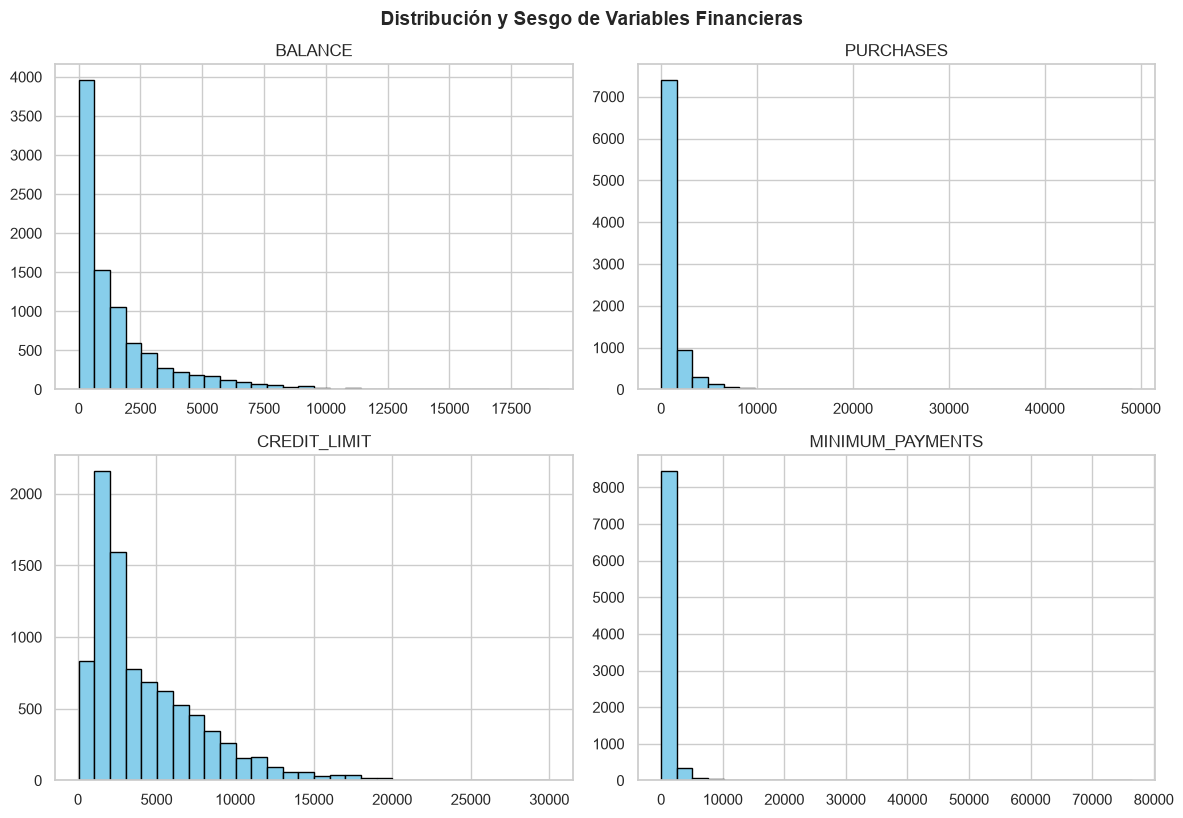

In [9]:
# Pintar histogramas de unas cuantas variables (df[cols].hist...) y observar el sesgo.
# 1. Seleccionar las variables clave para analizar su distribución
columnas_analisis = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'MINIMUM_PAYMENTS']

# 2. Configurar el tamaño de la figura y pintar los histogramas
df[columnas_analisis].hist(figsize=(12, 8), bins=30, color='skyblue', edgecolor='black')

# 3. Ajustar el diseño para que no se solapen los títulos y mostrar
plt.tight_layout()
plt.suptitle('Distribución y Sesgo de Variables Financieras', y=1.02, fontsize=14, fontweight='bold')
plt.show()

### Escalado

K-Means, PCA y casi todos los algoritmos de distancia son **sensibles a la escala**. `CREDIT_LIMIT` llega a miles y `PURCHASES_FREQUENCY` está entre 0 y 1: sin escalar, las variables grandes dominarían. Estandarizamos (media 0, desviación 1).

In [10]:

# 1. Instanciar el escalador
scaler = StandardScaler()

# 2. Ajustar y transformar los datos (obteniendo un array de NumPy)
X = scaler.fit_transform(df)

print("Datos escalados correctamente.")
print(f"Forma del array X: {X.shape}")
print(f"Media aproximada tras el escalado: {X.mean(axis=0)}")

Datos escalados correctamente.
Forma del array X: (8950, 17)
Media aproximada tras el escalado: [ 8.89170798e-17  2.28643919e-16  0.00000000e+00  3.17560999e-17
  2.54048799e-17  1.01619520e-16 -1.84185380e-16 -8.89170798e-17
  4.60463449e-17  5.55731749e-17 -2.54048799e-17 -2.54048799e-17
  1.27024400e-16 -3.81073199e-17  5.71609799e-17  0.00000000e+00
  2.79453679e-16]


## PCA

Con 17 variables no podemos pintar un scatter directo. Usamos PCA para (1) ver cuánta información retiene cada componente y (2) proyectar a 2D.

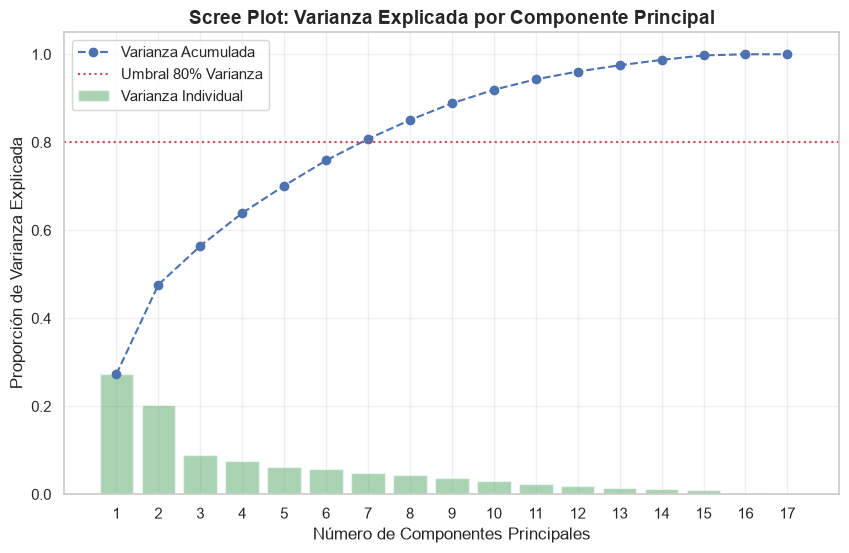

Varianza explicada acumulada por componente:
Componentes 1 a 1: 27.30%
Componentes 1 a 2: 47.61%
Componentes 1 a 3: 56.42%
Componentes 1 a 4: 63.90%
Componentes 1 a 5: 70.13%
Componentes 1 a 6: 75.87%
Componentes 1 a 7: 80.75%
Componentes 1 a 8: 85.05%
Componentes 1 a 9: 88.85%
Componentes 1 a 10: 91.93%
Componentes 1 a 11: 94.30%
Componentes 1 a 12: 96.08%
Componentes 1 a 13: 97.50%
Componentes 1 a 14: 98.72%
Componentes 1 a 15: 99.73%
Componentes 1 a 16: 100.00%
Componentes 1 a 17: 100.00%


In [ ]:


# 1. Ajustar PCA con todas las variables del dataset (sin fijar n_components)
pca = PCA()
pca.fit(X)

# Obtener la varianza explicada por cada componente y la acumulada
varianza_individual = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_individual)

# 2. Pintar la varianza explicada acumulada (Scree Plot)
plt.figure(figsize=(10, 6))

# Dibujar la línea de varianza acumulada
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--', color='b', label='Varianza Acumulada')
# Dibujar las barras de varianza individual
plt.bar(range(1, len(varianza_individual) + 1), varianza_individual, alpha=0.5, color='g', label='Varianza Individual')

# Línea de referencia en el 80%
plt.axhline(y=0.80, color='r', linestyle=':', label='Umbral 80% Varianza')

# Configuraciones de las etiquetas del gráfico
plt.title('Scree Plot: Varianza Explicada por Componente Principal', fontsize=14, fontweight='bold')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Explicada')
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# Mostrar los valores numéricos acumulados para decidir con precisión
print("Varianza explicada acumulada por componente:")
for i, var in enumerate(varianza_acumulada):
    print(f"Componentes 1 a {i+1}: {var*100:.2f}%")

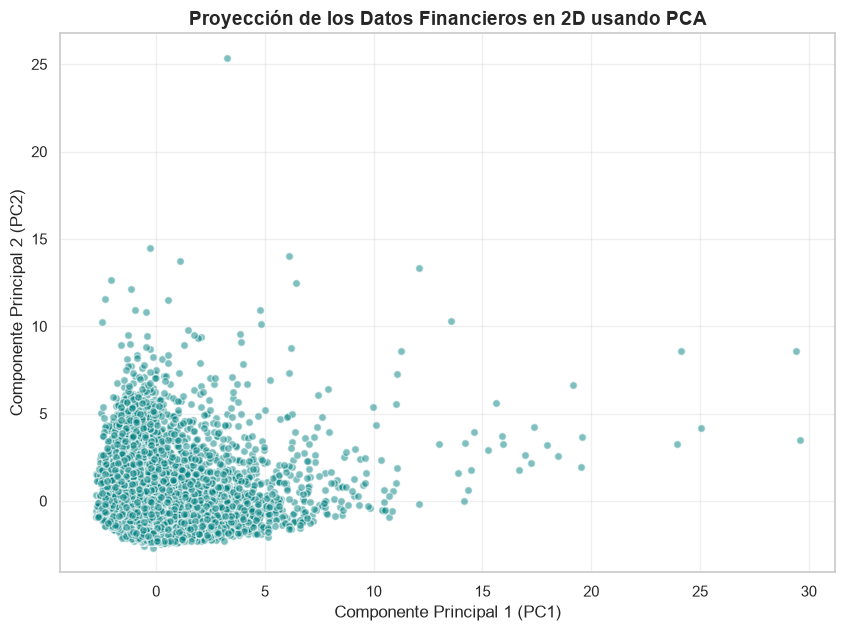

Las 2 primeras componentes principales retienen el 47.61% de la varianza total.


In [13]:
# 1. Instanciar y aplicar PCA reduciendo a 2 componentes principales
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X)

# Convertirlo a DataFrame para manipularlo y graficarlo cómodamente
df_pca = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])

# 2. Pintar el scatter plot (sin colores porque aún no tenemos clústeres asignados)
plt.figure(figsize=(10, 7))
plt.scatter(df_pca['Componente Principal 1'], df_pca['Componente Principal 2'], 
            alpha=0.5, color='teal', edgecolor='w', s=30)

plt.title('Proyección de los Datos Financieros en 2D usando PCA', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.grid(True, alpha=0.3)
plt.show()

# Mostrar cuánta varianza total retienen estas dos únicas componentes
varianza_2d = pca_2d.explained_variance_ratio_.sum() * 100
print(f"Las 2 primeras componentes principales retienen el {varianza_2d:.2f}% de la varianza total.")

A diferencia de las setas, aquí no vemos grupos separados a simple vista: es más bien una **nube continua**. El clustering nos ayudará a trazar fronteras útiles dentro de ella.

## Clustering: ¿cuántos segmentos? Codo + Silhouette

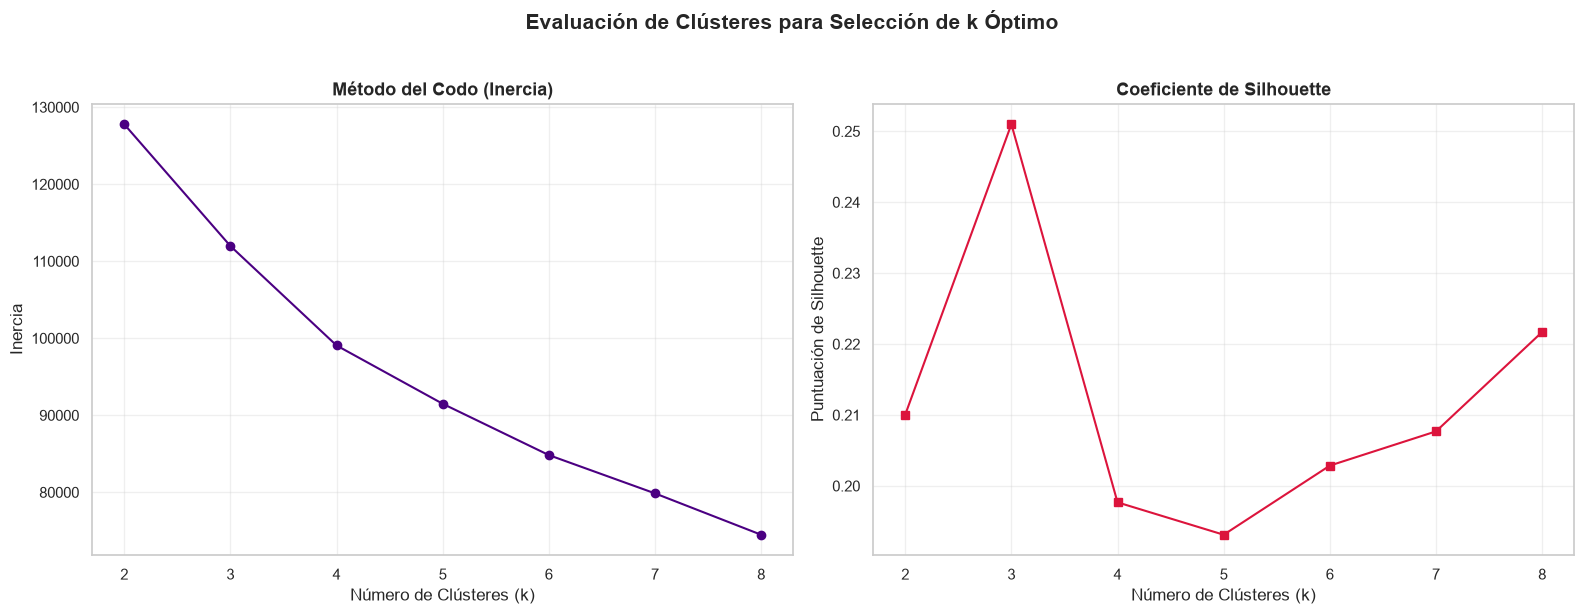

In [16]:
# Definir el rango de clústeres a evaluar
k_values = range(2, 9)
inercias = []
silhouettes = []

# 1. Ajustar KMeans y guardar inercia + silhouette por cada k
for k in k_values:
    # Corrección: El parámetro correcto es n_clusters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    
    # Guardar la inercia (Suma de distancias al cuadrado al centroide más cercano)
    inercias.append(kmeans.inertia_)
    
    # Guardar el coeficiente de Silhouette
    score = silhouette_score(X, kmeans.labels_)
    silhouettes.append(score)

# 2. Pintar las dos curvas en paralelo (subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico del Método del Codo (Inercia)
ax1.plot(k_values, inercias, marker='o', linestyle='-', color='indigo')
ax1.set_title('Método del Codo (Inercia)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Número de Clústeres (k)')
ax1.set_ylabel('Inercia')
ax1.set_xticks(k_values)
ax1.grid(True, alpha=0.3)

# Gráfico del Coeficiente de Silhouette
ax2.plot(k_values, silhouettes, marker='s', linestyle='-', color='crimson')
ax2.set_title('Coeficiente de Silhouette', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Clústeres (k)')
ax2.set_ylabel('Puntuación de Silhouette')
ax2.set_xticks(k_values)
ax2.grid(True, alpha=0.3)

plt.suptitle('Evaluación de Clústeres para Selección de k Óptimo', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### K-Means final

In [19]:
# Entrenar KMeans con best_k, guardar las etiquetas y mirar el tamano de cada cluster

# 1. Definir el k óptimo elegido (cambia el número si prefieres otro tras ver tus gráficas)
best_k = 3 

# 2. Instanciar y entrenar el KMeans final
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_final.fit(X)

# 3. Guardar las etiquetas en el DataFrame original y en el de PCA para visualizaciones futuras
df['Cluster'] = kmeans_final.labels_

# 4. Mirar el tamaño de cada clúster (conteo absoluto y porcentaje)
conteo_clusters = df['Cluster'].value_counts().sort_index()
porcentaje_clusters = (df['Cluster'].value_counts(normalize=True) * 100).sort_index()

print("Distribución de clientes por clúster:")
for cluster, (cantidad, porcentaje) in enumerate(zip(conteo_clusters, porcentaje_clusters)):
    print(f"Clúster {cluster}: {cantidad} clientes ({porcentaje:.2f}%)")


Distribución de clientes por clúster:
Clúster 0: 1275 clientes (14.25%)
Clúster 1: 6114 clientes (68.31%)
Clúster 2: 1561 clientes (17.44%)


### Comparativa de algoritmos

Sin etiqueta, comparamos con **métricas internas**: *silhouette* y *Calinski-Harabasz* (más alto = mejor) y *Davies-Bouldin* (más bajo = mejor).

In [21]:


# 1. Definir la función de evaluación con métricas internas
def evaluar(nombre, labels, X):
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    # Devolvemos un diccionario con los resultados formateados
    return {
        "Algoritmo": nombre,
        "Silhouette (↑)": round(sil, 4),
        "Davies-Bouldin (↓)": round(db, 4),
        "Calinski-Harabasz (↑)": round(ch, 4)
    }

# Fijamos el número de clústeres deseado
k = 3
resultados = []

# --- MOCK / ENTRENAMIENTO DE LOS TRES ALGORITMOS ---

# A. K-Means
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X)
resultados.append(evaluar("K-Means", labels_kmeans, X))

# B. Clustering Aglomerativo (Jerárquico)
# Nota: Si el dataset es extremadamente grande (>10k filas), puede consumir mucha memoria.
aglomerativo = AgglomerativeClustering(n_clusters=k)
labels_aglo = aglomerativo.fit_predict(X)
resultados.append(evaluar("Aglomerativo", labels_aglo, X))

# C. GMM (Gaussian Mixture Models)
gmm = GaussianMixture(n_components=k, random_state=42, n_init=1)
labels_gmm = gmm.fit_predict(X)
resultados.append(evaluar("GMM", labels_gmm, X))

# 2. Construir el DataFrame comparativo para analizar los resultados
df_comparativa = pd.DataFrame(resultados)
display(df_comparativa)

,Algoritmo,Silhouette (↑),Davies-Bouldin (↓),Calinski-Harabasz (↑)
0,K-Means,0.2510,1.5920,1605.0264
1,Aglomerativo,0.1674,1.8496,1239.3256
2,GMM,0.0978,2.9968,815.7820


### Dendrograma

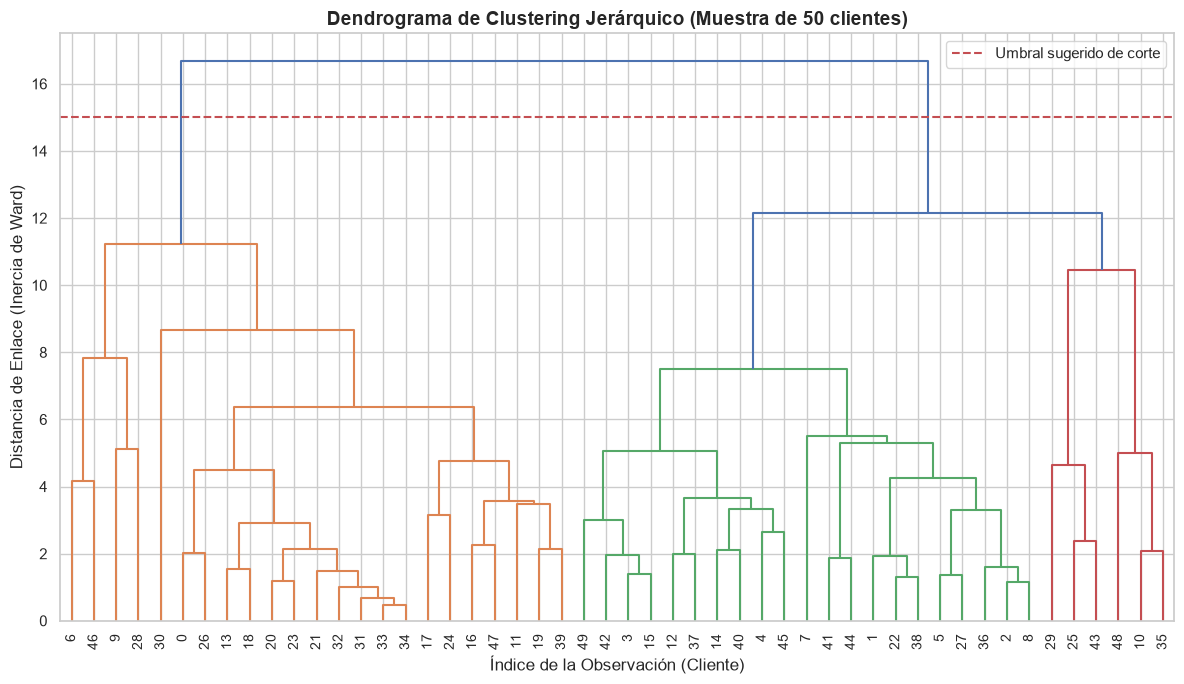

In [22]:
# linkage + dendrogram sobre una muestra de X


# 1. Fijar una semilla para reproducibilidad y tomar una muestra aleatoria (p.ej. 50 observaciones)
np.random.seed(42)
indices_muestra = np.random.choice(X.shape[0], size=50, replace=False)
X_muestra = X[indices_muestra]

# 2. Calcular la matriz de enlace utilizando el método de Ward
# El método de Ward es el más consistente con la filosofía de K-Means
Z = linkage(X_muestra, method='ward')

# 3. Pintar el dendrograma
plt.figure(figsize=(12, 7))
dendrogram(
    Z,
    leaf_rotation=90.,  # Rota los labels del eje X para que se lean bien
    leaf_font_size=10., # Tamaño de fuente de los índices de las observaciones
    color_threshold=0.7 * max(Z[:, 2]) # Colorea los clústeres principales automáticamente
)

plt.title('Dendrograma de Clustering Jerárquico (Muestra de 50 clientes)', fontsize=14, fontweight='bold')
plt.xlabel('Índice de la Observación (Cliente)')
plt.ylabel('Distancia de Enlace (Inercia de Ward)')
plt.axhline(y=15, color='r', linestyle='--', label='Umbral sugerido de corte') # Puedes ajustar el 'y' según tu gráfica
plt.legend(loc='best')
plt.tight_layout()
plt.show()

### DBSCAN: ¿hay clusters de densidad aquí?

Probamos DBSCAN. Veréis que en alta dimensión tiende a juntar casi todo en **un solo cluster** y marcar el resto como **ruido**. Eso nos dice algo importante: estos datos son una nube continua, no grupos separados por densidad. Aquí DBSCAN funciona mejor como **detector de atípicos** que como segmentador.

In [23]:
# Ejecutar DBSCAN sobre la proyeccion PCA(2). Observar cuantos clusters y cuanto ruido.


# 1. Recuperar o asegurar la proyección a 2D de PCA (X_pca)
# Usamos los datos bidimensionales que calculaste anteriormente
# X_pca tiene forma (n_muestras, 2)

# 2. Configurar y ajustar DBSCAN
# Ajustamos unos parámetros iniciales razonables para datos ya normalizados por PCA
dbscan = DBSCAN(eps=0.3, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_pca)

# 3. Analizar la estructura de los resultados
# En DBSCAN, las etiquetas -1 representan el ruido (outliers)
n_ruido = list(labels_dbscan).count(-1)
n_clusters = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)

print("--- Resultados de DBSCAN en 2D ---")
print(f"Número de clústeres encontrados: {n_clusters}")
print(f"Número de puntos marcados como ruido (outliers): {n_ruido} ({n_ruido / len(X_pca) * 100:.2f}%)")

# 4. Ver la distribución de puntos por clúster (excluyendo el ruido)
if n_clusters > 0:
    print("\nTamaño de los clústeres:")
    valores, conteos = np.unique(labels_dbscan[labels_dbscan != -1], return_counts=True)
    for val, con in zip(valores, conteos):
        print(f"  Clúster {val}: {con} clientes")

--- Resultados de DBSCAN en 2D ---
Número de clústeres encontrados: 4
Número de puntos marcados como ruido (outliers): 486 (5.43%)

Tamaño de los clústeres:
  Clúster 0: 8424 clientes
  Clúster 1: 12 clientes
  Clúster 2: 17 clientes
  Clúster 3: 11 clientes


### Visualización de los segmentos (t-SNE)

Proyectamos con t-SNE (sobre una muestra) y coloreamos por el segmento de K-Means.

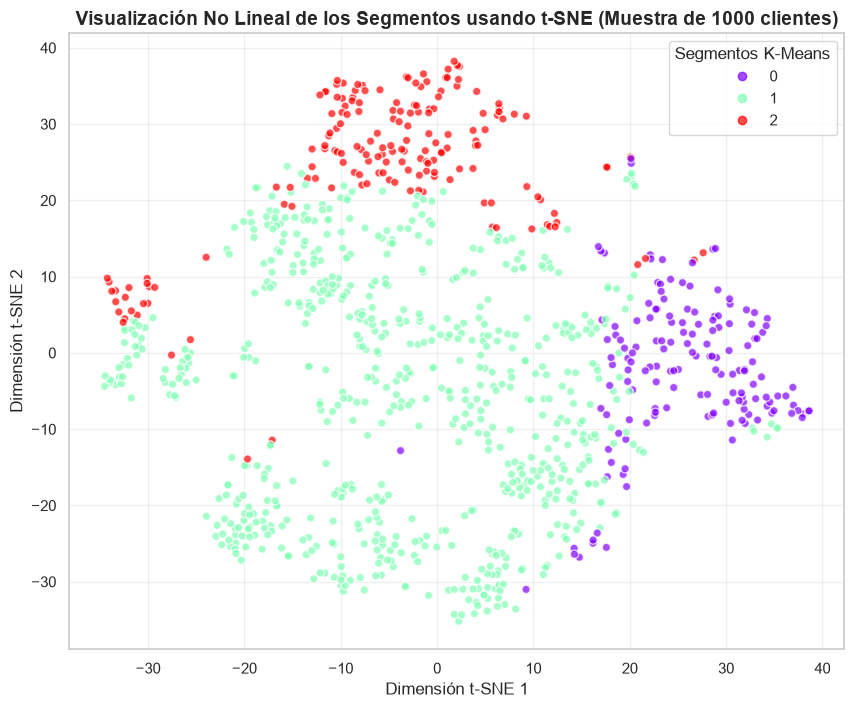

In [27]:
# t-SNE sobre una muestra de X, coloreado por el cluster de KMeans


# 1. Tomar una muestra aleatoria (ej. 1000 clientes) para agilizar t-SNE
np.random.seed(42)
indices_muestra = np.random.choice(X.shape[0], size=1000, replace=False)

X_muestra = X[indices_muestra]
# Extraemos también las etiquetas de KMeans correspondientes a esos mismos clientes
labels_muestra = df['Cluster'].iloc[indices_muestra].values

# 2. Configurar y aplicar t-SNE (reducir a 2 componentes)
# Quitamos n_iter para que use el comportamiento optimizado por defecto de la librería
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_muestra)

# 3. Crear un DataFrame temporal para facilitar el mapeo de colores
df_tsne = pd.DataFrame(X_tsne, columns=['t-SNE 1', 't-SNE 2'])
df_tsne['Cluster'] = labels_muestra

# 4. Pintar el scatter plot coloreando por los segmentos de K-Means
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_tsne['t-SNE 1'], df_tsne['t-SNE 2'], 
            c=df_tsne['Cluster'], cmap='rainbow', alpha=0.7, edgecolor='w', s=35)

# Añadir la leyenda de los clústeres
plt.legend(*scatter.legend_elements(), title="Segmentos K-Means", loc="best")

plt.title('Visualización No Lineal de los Segmentos usando t-SNE (Muestra de 1000 clientes)', fontsize=14, fontweight='bold')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.grid(True, alpha=0.3)
plt.show()

## Interpretación de los segmentos

Lo más importante en segmentación: **¿qué caracteriza a cada grupo?** Calculamos la media de cada variable por cluster y la estandarizamos entre clusters (rojo = por encima de la media, azul = por debajo). Así leemos el «perfil» de cada segmento.

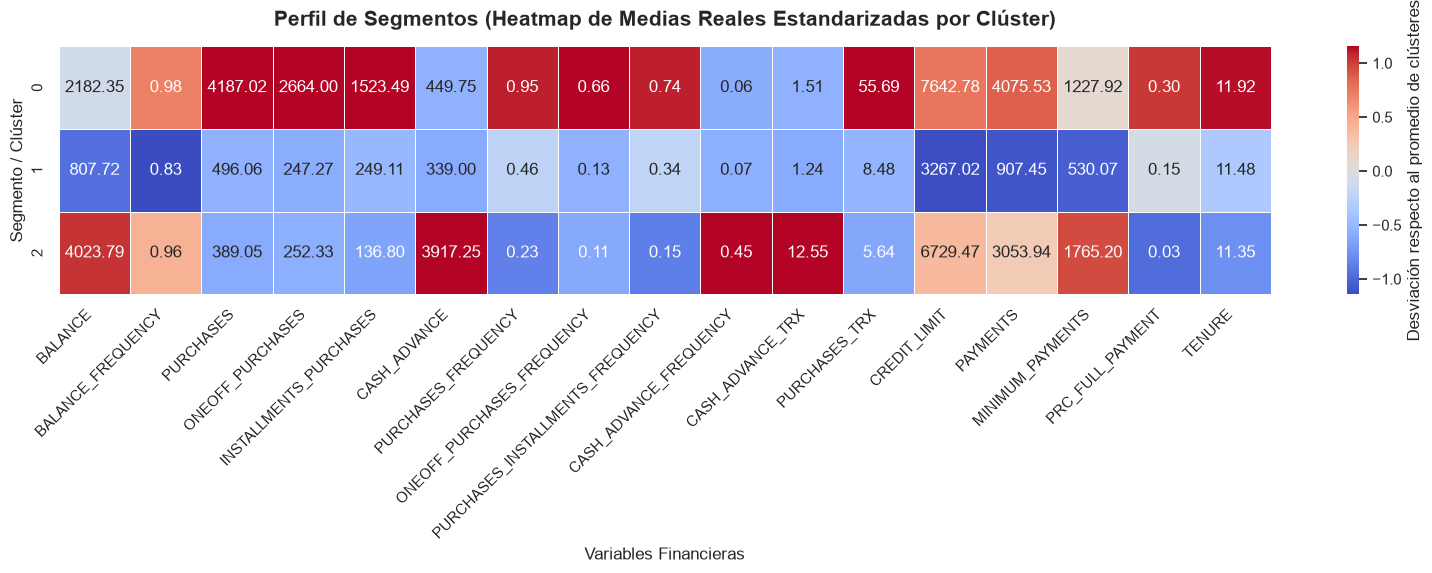

In [28]:
# 1. Anadir la columna 'cluster' al df original (sin escalar)
# 2. Calcular la media de cada variable por cluster
# 3. Estandarizar entre clusters y pintar un heatmap (perfil de cada segmento)

# 1. Asegurar que la columna 'Cluster' está en el df original (si no lo habías guardado antes)
# df['Cluster'] = kmeans_final.labels_

# 2. Calcular la media de cada variable para cada clúster
# Agrupamos por clúster y calculamos el promedio de todas las métricas
df_perfiles = df.groupby('Cluster').mean()

# 3. Estandarizar entre clústeres (Z-score por columna) para que el heatmap sea legible
# Esto permite comparar variables con escalas muy distintas (ej. frecuencias de 0 a 1 vs límites de crédito de miles)
df_perfiles_escalado = (df_perfiles - df_perfiles.mean()) / df_perfiles.std()

# 4. Pintar el Heatmap de Perfiles
plt.figure(figsize=(16, 6))
sns.heatmap(df_perfiles_escalado, 
            cmap='coolwarm',  # Rojo = Por encima de la media, Azul = Por debajo
            annot=df_perfiles.round(2),  # Mostramos los valores reales promedios dentro de cada celda
            fmt=".2f", 
            linewidths=0.5,
            cbar_kws={'label': 'Desviación respecto al promedio de clústeres'})

plt.title('Perfil de Segmentos (Heatmap de Medias Reales Estandarizadas por Clúster)', fontsize=15, fontweight='bold', y=1.05)
plt.xlabel('Variables Financieras')
plt.ylabel('Segmento / Clúster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Leyendo el heatmap se pueden nombrar los segmentos en términos de **negocio**, por ejemplo: clientes de alto saldo y muchas compras (VIP), clientes que tiran de adelantos de efectivo (riesgo), clientes poco activos, etc. Ese nombre y la estrategia asociada es justo el entregable que pide el caso.

## Detección de anomalías (Isolation Forest)

Identificamos los clientes con comportamiento más atípico (posible fraude, errores de datos o clientes premium fuera de norma).

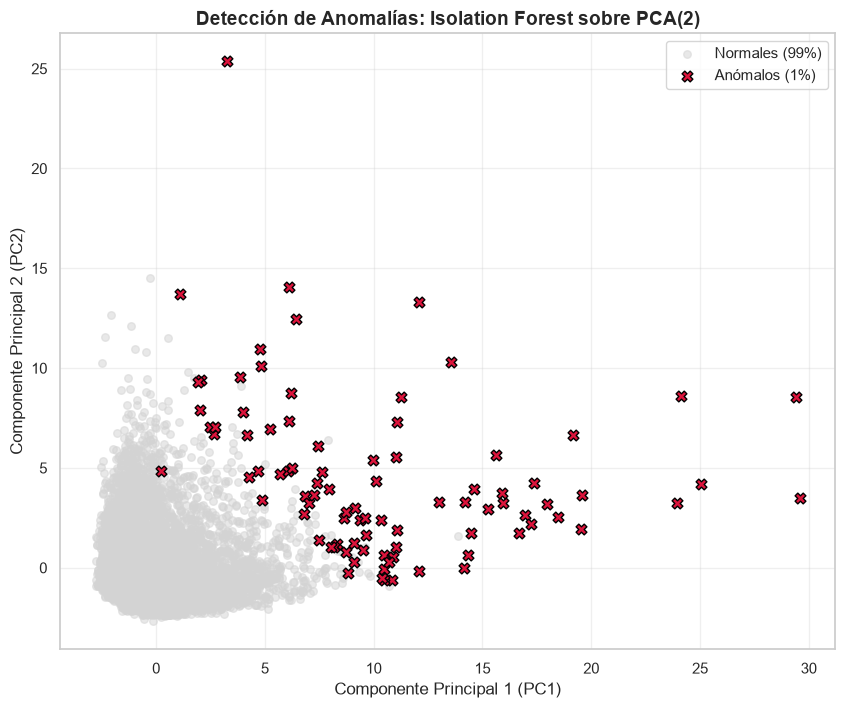

Número de clientes identificados como anómalos (1%): 90


In [32]:
# IsolationForest sobre X, marcar los atipicos (-1) y pintarlos sobre PCA(2)



# 1. Recuperar o asegurar la proyección a 2D de PCA (X_pca)
# (Reutilizamos X_pca que ya calculaste anteriormente)
if 'X_pca' not in locals():
    pca_2d = PCA(n_components=2)
    X_pca = pca_2d.fit_transform(X)

# 2. Entrenar y predecir con Isolation Forest
# Eliminamos n_init para usar los parámetros correctos de IsolationForest
iso_forest = IsolationForest(contamination=0.01, random_state=42)
if_labels = iso_forest.fit_predict(X) # Entrenamos sobre el espacio de alta dimensión (X)

# En Isolation Forest, -1 es anómalo, 1 es normal
if_labels_str = np.where(if_labels == -1, 'Anómalo', 'Normal')

# 3. Crear DataFrame temporal para la visualización
df_if = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_if['Atípicos'] = if_labels_str

# 4. Pintar el Scatter Plot sobre PCA(2), coloreando por Isolation Forest
plt.figure(figsize=(10, 8))

# Pintar clientes normales
normal = df_if[df_if['Atípicos'] == 'Normal']
plt.scatter(normal['PC1'], normal['PC2'], c='lightgray', alpha=0.5, s=30, label='Normales (99%)')

# Pintar clientes anómalos con un color llamativo y mayor tamaño
atipicos = df_if[df_if['Atípicos'] == 'Anómalo']
plt.scatter(atipicos['PC1'], atipicos['PC2'], c='crimson', alpha=1.0, s=60, edgecolor='black', label='Anómalos (1%)', marker='X')

plt.title('Detección de Anomalías: Isolation Forest sobre PCA(2)', fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal 1 (PC1)')
plt.ylabel('Componente Principal 2 (PC2)')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.show()

# 5. Analizar el perfil de los anómalos (opcional, para tu interpretación)
n_anomalos = list(if_labels).count(-1)
print(f"Número de clientes identificados como anómalos (1%): {n_anomalos}")

---
## Para ir más allá (opcional)

- **Ingeniería de KPIs**: derivar variables como *ratio de uso del límite* (`BALANCE / CREDIT_LIMIT`) o *compra media por transacción* suele mejorar mucho los segmentos.
- **UMAP / HDBSCAN** para visualización y clustering por densidad más robusto.
- **Transformación logarítmica** de las variables sesgadas antes de escalar.

## Conclusiones

- Sin etiqueta, la segmentación se valida con métricas internas (*silhouette*, etc.) y, sobre todo, con la **interpretabilidad** de los perfiles.
- Imputar y **escalar** fue imprescindible aquí (a diferencia de las setas).
- K-Means, GMM y Aglomerativo dan segmentos coherentes; DBSCAN reveló que los datos son una nube continua (mejor como detector de atípicos).
- El heatmap de perfiles convierte los clusters en **segmentos de negocio accionables**.